## Module 1 — Data Loading & Exploration  

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [101]:
# ── Set your path ──────────────────────────────────────────
PATH = r'C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\'

In [102]:
# Load data 
orders      = pd.read_csv(PATH + 'orders.csv')
products    = pd.read_csv(PATH + 'products.csv')
departments = pd.read_csv(PATH + 'departments.csv')
aisles      = pd.read_csv(PATH + 'aisles.csv', sep=';')

In [103]:
# Clean column names
for df in [orders, products, departments, aisles]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [104]:
print("=== ORDERS ===")
print(orders.head())
print(orders.dtypes)
print(f"\nShape: {orders.shape}")
print(f"Nulls:\n{orders.isnull().sum()}")

print("\n=== PRODUCTS ===")
print(products.head())
print(products.dtypes)

print("\n=== DEPARTMENTS ===")
print(departments.head())

print("\n=== AISLES ===")
print(aisles.head())

=== ORDERS ===
       id  order_date ship_mode customer_id    sales
0  100006  2014-09-07  Standard    DK-13375  377.970
1  100090  2014-07-08  Standard    EB-13705  699.192
2  100293  2014-03-14  Standard    NF-18475   91.056
3  100328  2014-01-28  Standard    JC-15340    3.928
4  100363  2014-04-08  Standard    JM-15655   21.376
id               int64
order_date      object
ship_mode       object
customer_id     object
sales          float64
dtype: object

Shape: (5009, 5)
Nulls:
id             0
order_date     0
ship_mode      0
customer_id    0
sales          0
dtype: int64

=== PRODUCTS ===
  productid      productname  price  category
0      C101     Sports Shoes  79.99  Clothing
1      C102   Running Shorts  24.99  Clothing
2      C103   Cotton T-Shirt  14.99  Clothing
3      C104     Denim Jacket  59.99  Clothing
4      C105  Women’s Handbag  45.99  Clothing
productid       object
productname     object
price          float64
category        object
dtype: object

=== DEPARTMENT

In [105]:
# Fix data types 
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['sales']      = pd.to_numeric(orders['sales'], errors='coerce')
orders['year']       = orders['order_date'].dt.year
orders['month']      = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.strftime('%b')
orders['day_name']   = orders['order_date'].dt.strftime('%A')
orders['quarter']    = orders['order_date'].dt.quarter

print("\n=== CLEANED ORDERS SAMPLE ===")
print(orders.head())


=== CLEANED ORDERS SAMPLE ===
       id order_date ship_mode customer_id    sales  year  month month_name  \
0  100006 2014-09-07  Standard    DK-13375  377.970  2014      9        Sep   
1  100090 2014-07-08  Standard    EB-13705  699.192  2014      7        Jul   
2  100293 2014-03-14  Standard    NF-18475   91.056  2014      3        Mar   
3  100328 2014-01-28  Standard    JC-15340    3.928  2014      1        Jan   
4  100363 2014-04-08  Standard    JM-15655   21.376  2014      4        Apr   

  day_name  quarter  
0   Sunday        3  
1  Tuesday        3  
2   Friday        1  
3  Tuesday        1  
4  Tuesday        2  


## MODULE 2 — EXPLORATORY DATA ANALYSIS

In [107]:
print("\n=== BASIC STATISTICS ===")
print(orders['sales'].describe().round(2))
print(f"\nTotal Revenue:    £{orders['sales'].sum():,.2f}")
print(f"Total Orders:     {orders['id'].nunique():,}")
print(f"Total Customers:  {orders['customer_id'].nunique():,}")
print(f"Avg Order Value:  £{orders['sales'].mean():,.2f}")
print(f"Date Range:       {orders['order_date'].min().date()} "
      f"to {orders['order_date'].max().date()}")


=== BASIC STATISTICS ===
count     5009.00
mean       458.61
std        954.73
min          0.56
25%         37.63
50%        151.96
75%        512.06
max      23661.23
Name: sales, dtype: float64

Total Revenue:    £2,297,200.86
Total Orders:     5,009
Total Customers:  793
Avg Order Value:  £458.61
Date Range:       2014-01-03 to 2017-12-30



=== SALES BY SHIP MODE ===
  ship_mode  total_sales  order_count  avg_sale
0     First    351428.42          787    446.54
1  Same Day    128363.12          264    486.22
2    Second    459193.57          964    476.34
3  Standard   1358215.74         2994    453.65


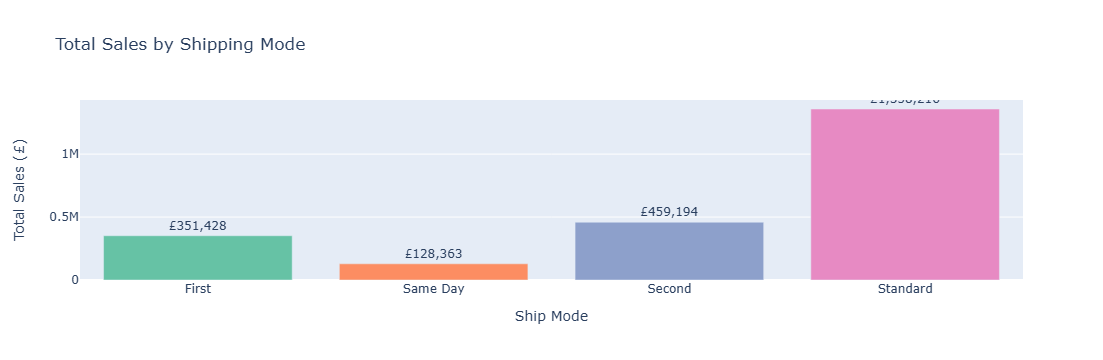

In [108]:
# Sales by ship mode 
ship_sales = (orders
              .groupby('ship_mode')['sales']
              .agg(['sum', 'count', 'mean'])
              .round(2)
              .reset_index())
ship_sales.columns = ['ship_mode', 'total_sales', 'order_count', 'avg_sale']
print("\n=== SALES BY SHIP MODE ===")
print(ship_sales)

fig = px.bar(ship_sales, x='ship_mode', y='total_sales',
             color='ship_mode',
             title='Total Sales by Shipping Mode',
             text='total_sales',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(texttemplate='£%{text:,.0f}', textposition='outside')
fig.update_layout(showlegend=False, xaxis_title='Ship Mode',
                  yaxis_title='Total Sales (£)')
fig.show()

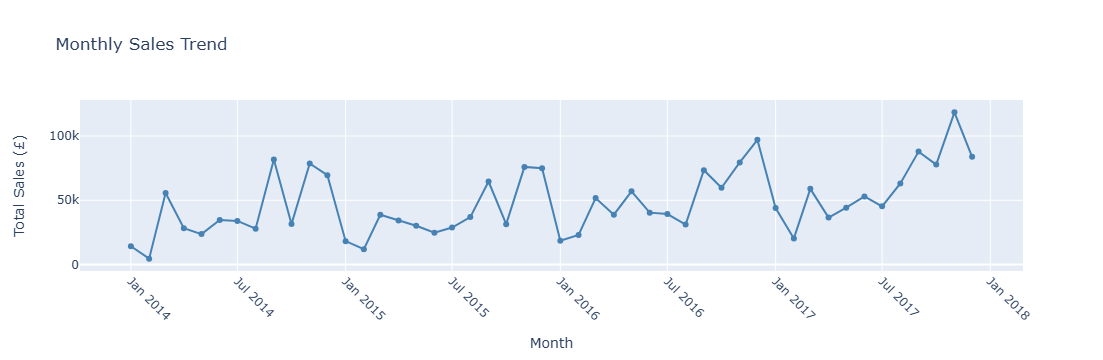

In [109]:
# Monthly sales trend 
monthly = (orders
           .groupby(['year', 'month', 'month_name'])['sales']
           .sum()
           .reset_index()
           .sort_values(['year', 'month']))

monthly['period'] = (monthly['year'].astype(str)
                     + '-' + monthly['month'].astype(str).str.zfill(2))

fig = px.line(monthly, x='period', y='sales',
              title='Monthly Sales Trend',
              markers=True,
              labels={'sales': 'Total Sales (£)', 'period': 'Month'},
              color_discrete_sequence=['steelblue'])
fig.update_xaxes(tickangle=45)
fig.show()

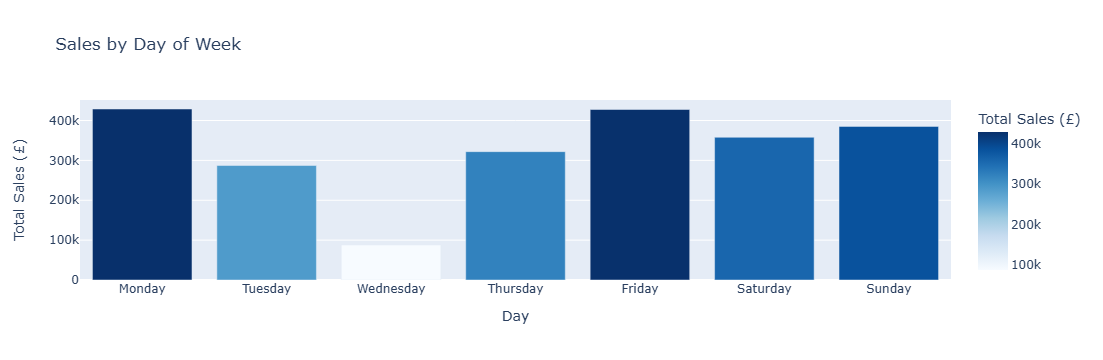

In [110]:
# Sales by day of week 
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

day_sales = (orders
             .groupby('day_name')['sales']
             .agg(['sum', 'count'])
             .reindex(day_order)
             .reset_index())
day_sales.columns = ['day', 'total_sales', 'order_count']

fig = px.bar(day_sales, x='day', y='total_sales',
             color='total_sales',
             title='Sales by Day of Week',
             color_continuous_scale='Blues',
             labels={'total_sales': 'Total Sales (£)', 'day': 'Day'})
fig.show()

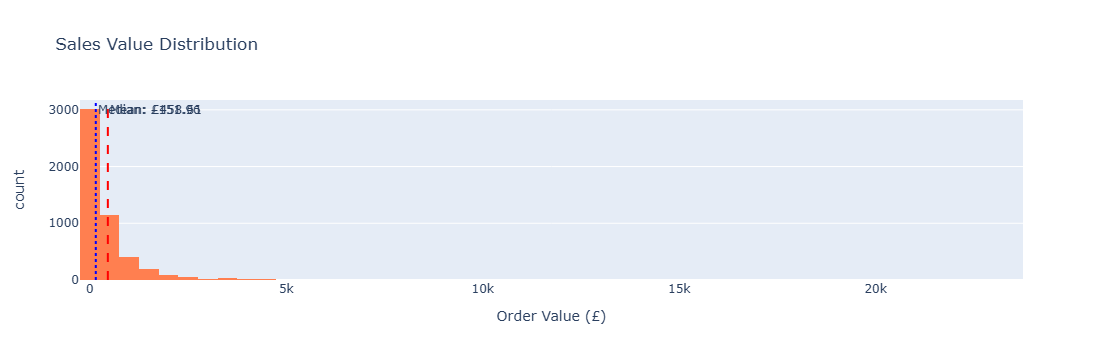

In [111]:
#  Sales distribution 
fig = px.histogram(orders, x='sales', nbins=50,
                   title='Sales Value Distribution',
                   labels={'sales': 'Order Value (£)'},
                   color_discrete_sequence=['coral'])
fig.add_vline(x=orders['sales'].mean(),
              line_dash='dash', line_color='red',
              annotation_text=f"Mean: £{orders['sales'].mean():.2f}")
fig.add_vline(x=orders['sales'].median(),
              line_dash='dot', line_color='blue',
              annotation_text=f"Median: £{orders['sales'].median():.2f}")
fig.show()

## MODULE 3 — RFM CUSTOMER SEGMENTATION

In [113]:
# Reference date = day after last order
ref_date = orders['order_date'].max() + pd.Timedelta(days=1)

rfm = (orders
       .groupby('customer_id')
       .agg(
           last_order_date = ('order_date', 'max'),
           frequency       = ('id',         'nunique'),
           monetary        = ('sales',       'sum')
       )
       .reset_index())

In [114]:
# Recency = days since last order (lower = better)
rfm['recency'] = (ref_date - rfm['last_order_date']).dt.days

print("\n=== RFM BASE TABLE ===")
print(rfm.describe().round(2))



=== RFM BASE TABLE ===
                     last_order_date  frequency  monetary  recency
count                            793     793.00    793.00   793.00
mean   2017-08-05 04:45:05.674653184       6.32   2896.85   147.80
min              2014-10-22 00:00:00       1.00      4.83     1.00
25%              2017-06-30 00:00:00       5.00   1146.05    31.00
50%              2017-10-16 00:00:00       6.00   2256.39    76.00
75%              2017-11-30 00:00:00       8.00   3785.28   184.00
max              2017-12-30 00:00:00      17.00  25043.05  1166.00
std                              NaN       2.55   2628.67   186.21


In [115]:
# Score into quintiles 
# Recency: lower days = better = score 5
rfm['r_score'] = pd.qcut(rfm['recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1])

rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

rfm[['r_score','f_score','m_score']] = (
    rfm[['r_score','f_score','m_score']].astype(int))

rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']


In [116]:
# Assign segments 
def segment_customer(score):
    if score >= 13:   return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['segment'] = rfm['rfm_total'].apply(segment_customer)

print("\n=== SEGMENT DISTRIBUTION ===")
print(rfm['segment'].value_counts())


=== SEGMENT DISTRIBUTION ===
segment
Loyal Customers        254
Potential Loyalists    219
Champions              124
At Risk                116
Lost Customers          80
Name: count, dtype: int64


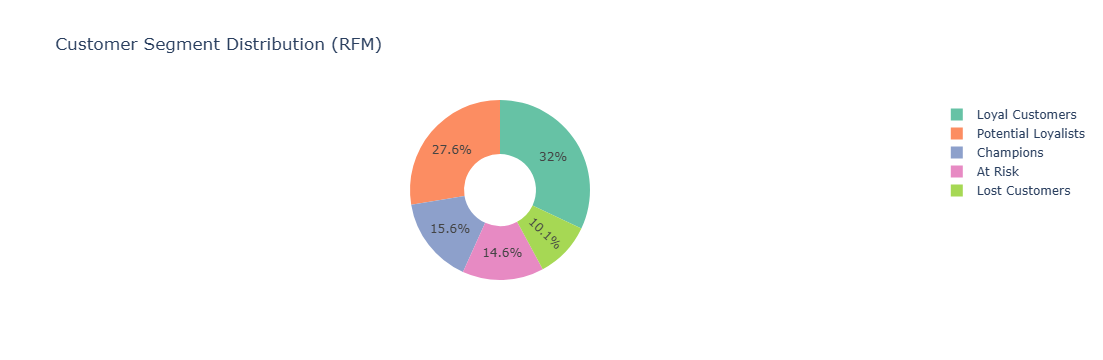

In [117]:
# Segment visualisations
seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']

fig = px.pie(seg_counts, names='segment', values='count',
             title='Customer Segment Distribution (RFM)',
             color_discrete_sequence=px.colors.qualitative.Set2,
             hole=0.4)
fig.show()



=== SEGMENT PROFILES ===
            segment  customers  avg_recency  avg_frequency  avg_monetary
            At Risk        116        227.9            4.2        1233.0
          Champions        124         28.1            9.4        5221.2
     Lost Customers         80        475.8            3.0         635.0
    Loyal Customers        254         75.1            7.4        3869.4
Potential Loyalists        219        137.7            5.6        2160.4


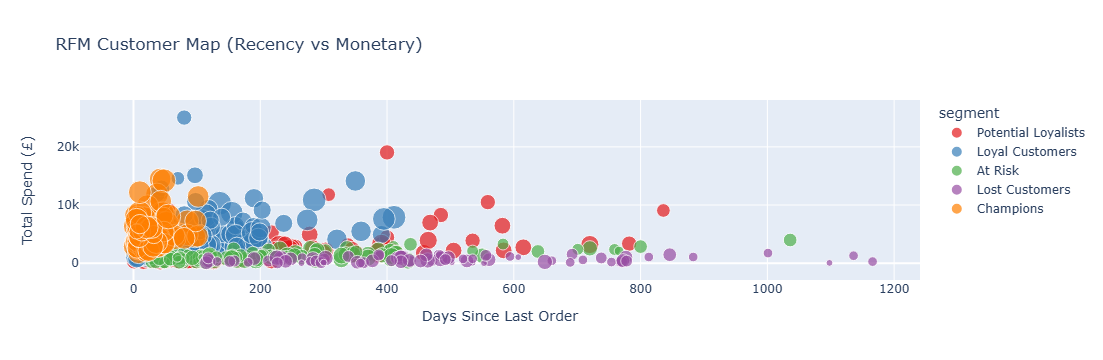

In [118]:
# Segment profile heatmap
seg_profile = (rfm
               .groupby('segment')
               .agg(
                   customers  = ('customer_id', 'count'),
                   avg_recency   = ('recency',   'mean'),
                   avg_frequency = ('frequency', 'mean'),
                   avg_monetary  = ('monetary',  'mean')
               )
               .round(1)
               .reset_index())

print("\n=== SEGMENT PROFILES ===")
print(seg_profile.to_string(index=False))

fig = px.scatter(rfm, x='recency', y='monetary',
                 size='frequency', color='segment',
                 title='RFM Customer Map (Recency vs Monetary)',
                 hover_data=['customer_id', 'rfm_total'],
                 color_discrete_sequence=px.colors.qualitative.Set1,
                 labels={'recency': 'Days Since Last Order',
                         'monetary': 'Total Spend (£)'})
fig.show()

## MODULE 4 — K-MEANS CLUSTERING

In [120]:
features        = rfm[['recency', 'frequency', 'monetary']].copy()
scaler          = StandardScaler()
features_scaled = scaler.fit_transform(features)


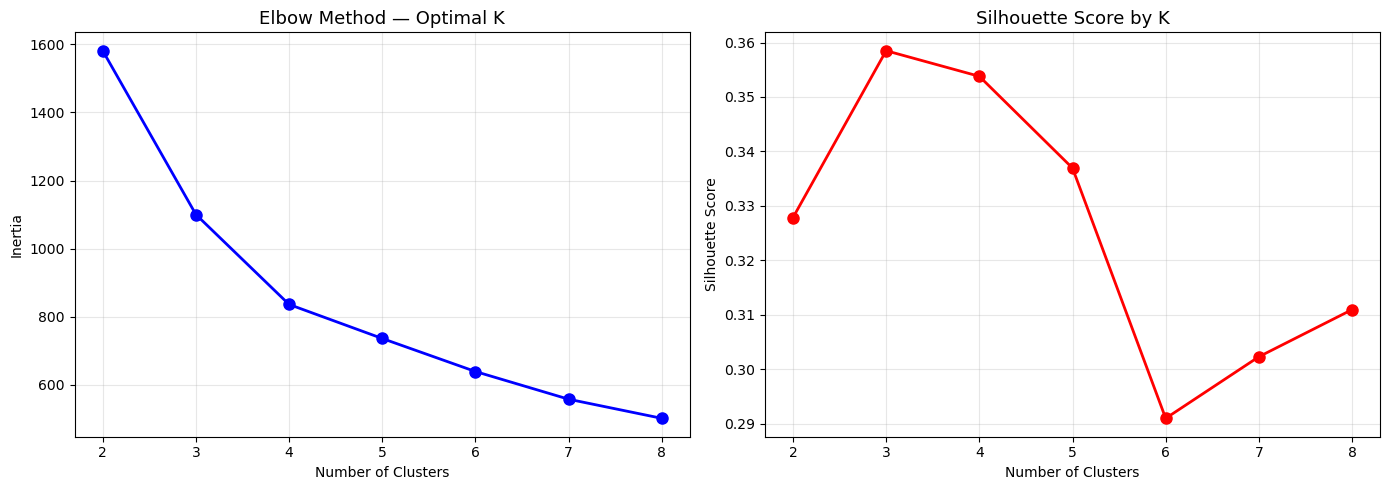

In [121]:
# Find optimal K 
inertia    = []
sil_scores = []
k_range    = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(
        silhouette_score(features_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Optimal K', fontsize=13)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontsize=13)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PATH + 'elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# Best K based on highest silhouette
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nOptimal K based on silhouette: {best_k}")


Optimal K based on silhouette: 3


In [123]:
# Fit final model 
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(features_scaled)

cluster_profile = (rfm
                   .groupby('cluster')
                   .agg(
                       size          = ('customer_id', 'count'),
                       avg_recency   = ('recency',     'mean'),
                       avg_frequency = ('frequency',   'mean'),
                       avg_monetary  = ('monetary',    'mean')
                   )
                   .round(1)
                   .reset_index())

print("\n=== K-MEANS CLUSTER PROFILES ===")
print(cluster_profile.to_string(index=False))



=== K-MEANS CLUSTER PROFILES ===
 cluster  size  avg_recency  avg_frequency  avg_monetary
       0   413         88.7            5.4        1773.8
       1   111        531.4            3.8        1636.9
       2   269         80.3            8.8        5141.0


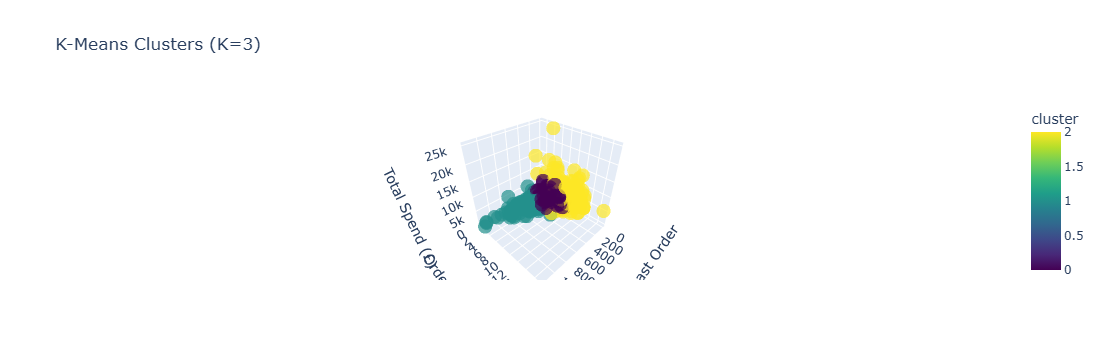

In [124]:
fig = px.scatter_3d(rfm,
                    x='recency', y='frequency', z='monetary',
                    color='cluster',
                    title=f'K-Means Clusters (K={best_k})',
                    opacity=0.7,
                    color_continuous_scale='Viridis',
                    labels={'recency':   'Days Since Last Order',
                            'frequency': 'Order Count',
                            'monetary':  'Total Spend (£)'})
fig.show()

## MODULE 5 — CHURN RISK SCORING

In [126]:
churn = rfm.copy()

def churn_risk(row):
    if row['recency'] > 180 and row['frequency'] <= 2:
        return 'High Risk'
    elif row['recency'] > 90 or row['frequency'] <= 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn['churn_risk'] = churn.apply(churn_risk, axis=1)

In [127]:
risk_summary = (churn
                .groupby('churn_risk')
                .agg(
                    customers     = ('customer_id', 'count'),
                    avg_recency   = ('recency',     'mean'),
                    avg_spend     = ('monetary',    'mean'),
                    avg_frequency = ('frequency',   'mean')
                )
                .round(1)
                .reset_index())

print("\n=== CHURN RISK SUMMARY ===")
print(risk_summary.to_string(index=False))


=== CHURN RISK SUMMARY ===
 churn_risk  customers  avg_recency  avg_spend  avg_frequency
  High Risk         28        613.4      622.2            1.7
   Low Risk        402         37.5     3319.5            7.2
Medium Risk        363        234.0     2604.3            5.6


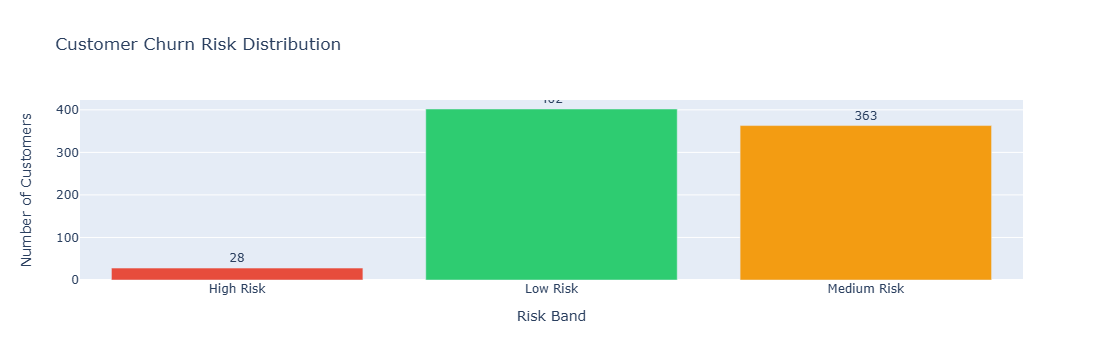

In [128]:
color_map = {
    'High Risk':   '#e74c3c',
    'Medium Risk': '#f39c12',
    'Low Risk':    '#2ecc71'
}

fig = px.bar(risk_summary, x='churn_risk', y='customers',
             color='churn_risk',
             color_discrete_map=color_map,
             title='Customer Churn Risk Distribution',
             text='customers',
             labels={'customers': 'Number of Customers',
                     'churn_risk': 'Risk Band'})
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

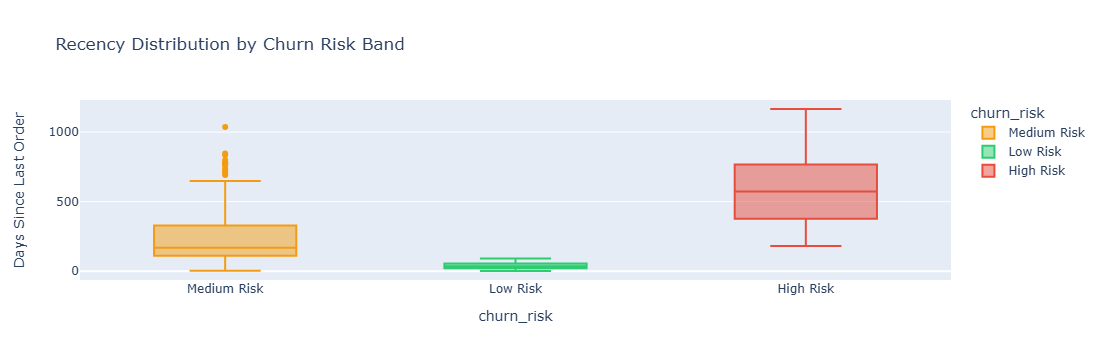

In [129]:
fig = px.box(churn, x='churn_risk', y='recency',
             color='churn_risk',
             color_discrete_map=color_map,
             title='Recency Distribution by Churn Risk Band',
             labels={'recency': 'Days Since Last Order'})
fig.show()


## MODULE 6 — SALES PERFORMANCE ANALYSIS

In [131]:
# Yearly revenue growth 
yearly = (orders
          .groupby('year')['sales']
          .agg(['sum', 'count', 'mean'])
          .reset_index())
yearly.columns = ['year', 'total_sales', 'order_count', 'avg_order_value']
yearly['yoy_growth'] = yearly['total_sales'].pct_change() * 100

print("\n=== YEARLY PERFORMANCE ===")
print(yearly.round(2).to_string(index=False))


=== YEARLY PERFORMANCE ===
 year  total_sales  order_count  avg_order_value  yoy_growth
 2014    484247.50          969           499.74         NaN
 2015    470532.51         1038           453.31       -2.83
 2016    609205.60         1315           463.27       29.47
 2017    733215.26         1687           434.63       20.36


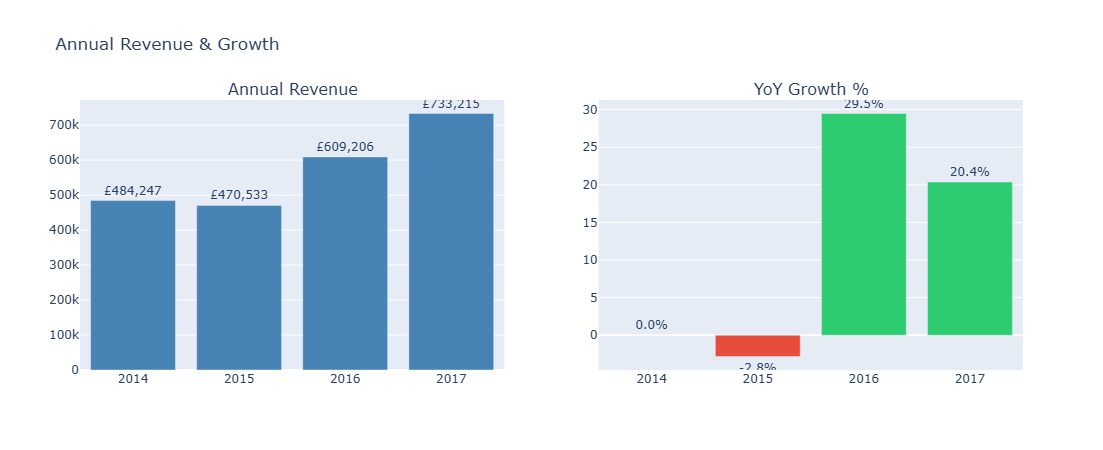

In [140]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Annual Revenue', 'YoY Growth %'])

fig.add_trace(
    go.Bar(x=yearly['year'].astype(str),
           y=yearly['total_sales'],
           marker_color='steelblue',
           text=yearly['total_sales'].round(0),
           texttemplate='£%{text:,.0f}',
           textposition='outside',
           name='Revenue'),
    row=1, col=1)

fig.add_trace(
    go.Bar(x=yearly['year'].astype(str),
           y=yearly['yoy_growth'],
           marker_color=yearly['yoy_growth'].apply(
               lambda x: '#2ecc71' if x > 0 else '#e74c3c'),
           text=yearly['yoy_growth'].round(1),
           texttemplate='%{text:.1f}%',
           textposition='outside',
           name='YoY Growth'),
    row=1, col=2)

fig.update_layout(title='Annual Revenue & Growth',
                  showlegend=False, height=450)
fig.show()



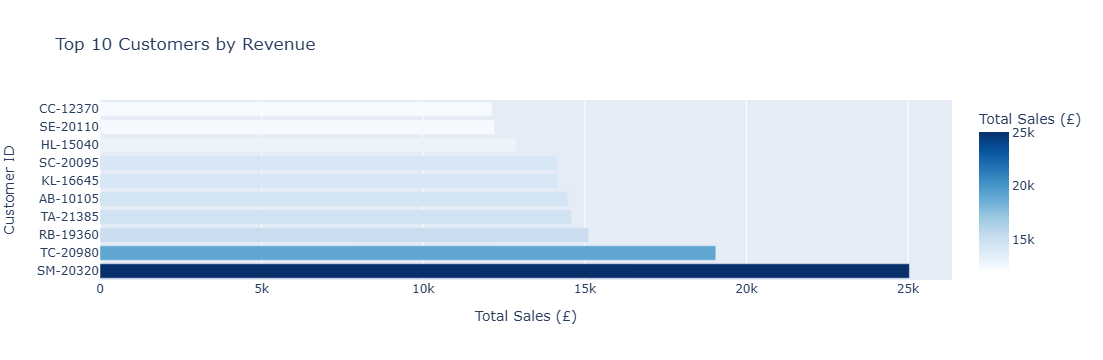

In [142]:
# Top 10 customers by revenue 
top_customers = (orders
                 .groupby('customer_id')['sales']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
top_customers.columns = ['customer_id', 'total_sales']

fig = px.bar(top_customers,
             x='total_sales', y='customer_id',
             orientation='h',
             color='total_sales',
             color_continuous_scale='Blues',
             title='Top 10 Customers by Revenue',
             labels={'total_sales':  'Total Sales (£)',
                     'customer_id':  'Customer ID'})
fig.show()

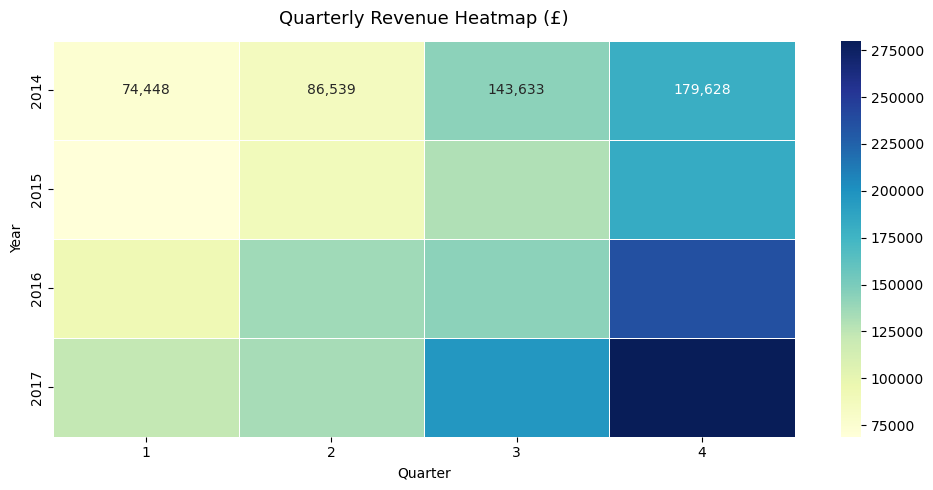

In [144]:
#  Quarterly revenue heatmap 
quarterly = (orders
             .groupby(['year', 'quarter'])['sales']
             .sum()
             .unstack()
             .round(0))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(quarterly,
            annot=True, fmt=',.0f',
            cmap='YlGnBu',
            linewidths=0.5,
            ax=ax)
ax.set_title('Quarterly Revenue Heatmap (£)', fontsize=13, pad=12)
ax.set_xlabel('Quarter')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(PATH + 'quarterly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## MODULE 7 — PRODUCT ANALYSIS

In [147]:
# Merge products with orders via customer spend proxy
print("\n=== PRODUCTS ===")
print(products.head(10))
print(products.dtypes)


=== PRODUCTS ===
  productid               productname  price  category
0      C101              Sports Shoes  79.99  Clothing
1      C102            Running Shorts  24.99  Clothing
2      C103            Cotton T-Shirt  14.99  Clothing
3      C104              Denim Jacket  59.99  Clothing
4      C105           Women’s Handbag  45.99  Clothing
5      J201           Silver Necklace  39.99   Jewelry
6      J202      Gold Plated Earrings  29.99   Jewelry
7      J203              Bracelet Set  19.99   Jewelry
8      J204  Diamond Ring (Synthetic)  89.99   Jewelry
9      J205             Pearl Pendant  49.99   Jewelry
productid       object
productname     object
price          float64
category        object
dtype: object



=== CATEGORY SUMMARY ===
category  product_count  avg_price  min_price  max_price
Clothing              5      45.19      14.99      79.99
 Jewelry              5      45.99      19.99      89.99


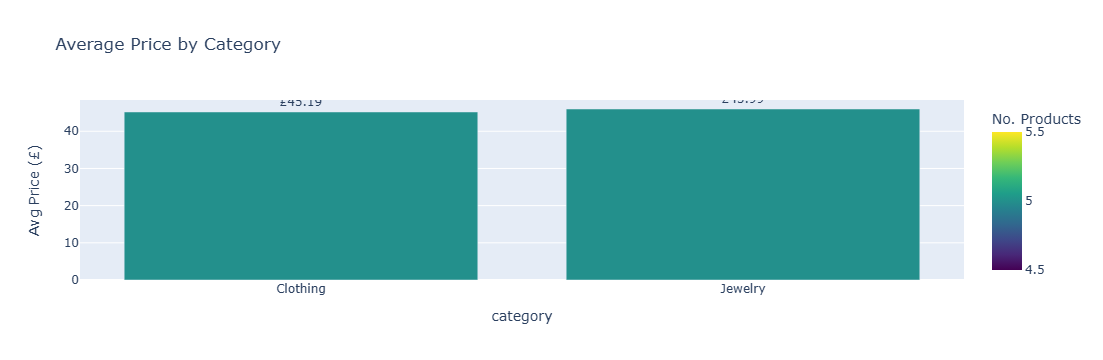

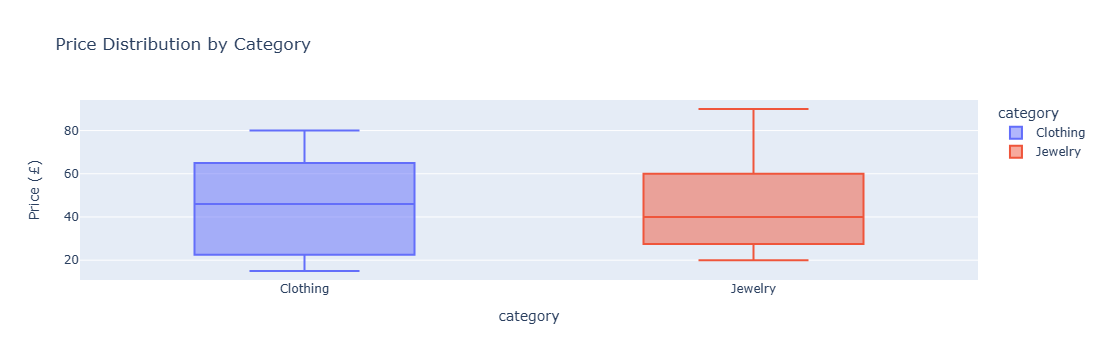

In [154]:
# Category-level analysis
if 'category' in products.columns:
    cat_summary = (products
                   .groupby('category')
                   .agg(
                       product_count = ('productid',   'count'),
                       avg_price     = ('price',       'mean'),
                       min_price     = ('price',       'min'),
                       max_price     = ('price',       'max')
                   )
                   .round(2)
                   .reset_index())

    print("\n=== CATEGORY SUMMARY ===")
    print(cat_summary.to_string(index=False))
    fig = px.bar(cat_summary, x='category', y='avg_price',
                 color='product_count',
                 title='Average Price by Category',
                 color_continuous_scale='Viridis',
                 text='avg_price',
                 labels={'avg_price': 'Avg Price (£)',
                         'product_count': 'No. Products'})
    fig.update_traces(texttemplate='£%{text:.2f}',
                      textposition='outside')
    fig.show()

    fig = px.box(products, x='category', y='price',
                 color='category',
                 title='Price Distribution by Category',
                 labels={'price': 'Price (£)'})
    fig.show()

## MODULE 8 — EXECUTIVE SUMMARY DASHBOARD

In [157]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Monthly Sales Trend',
        'Customer Segments (RFM)',
        'Sales by Ship Mode',
        'Churn Risk Distribution',
        'Top 10 Customers',
        'Quarterly Revenue Heatmap'
    ),
    specs=[[{'type': 'scatter'},
            {'type': 'pie'},
            {'type': 'bar'}],
           [{'type': 'bar'},
            {'type': 'bar'},
            {'type': 'heatmap'}]]
)

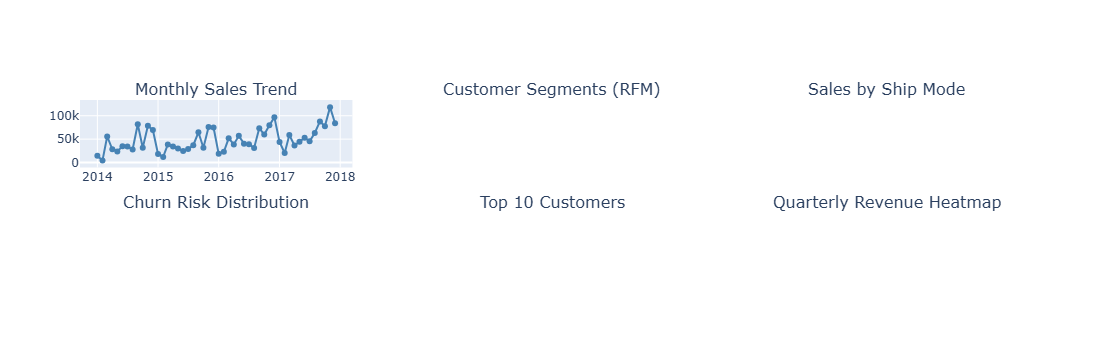

In [159]:
# Panel 1 — Monthly trend
fig.add_trace(
    go.Scatter(x=monthly['period'], y=monthly['sales'],
               mode='lines+markers',
               line=dict(color='steelblue', width=2),
               name='Monthly Sales'),
    row=1, col=1)


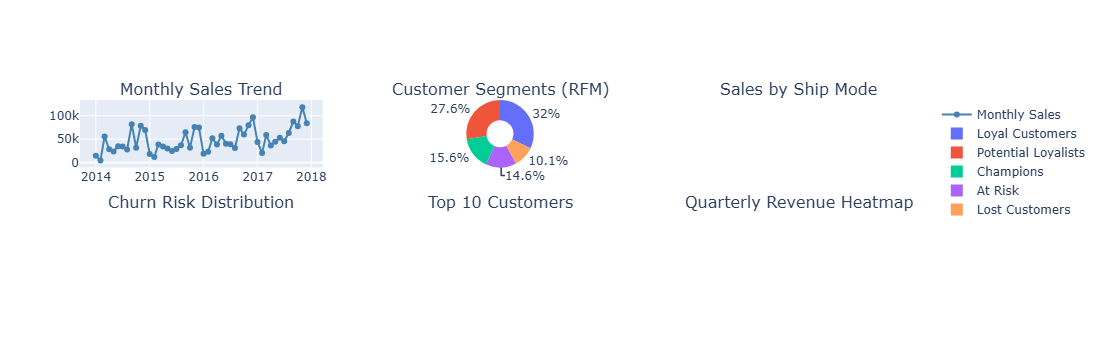

In [161]:
# Panel 2 — RFM pie
fig.add_trace(
    go.Pie(labels=seg_counts['segment'],
           values=seg_counts['count'],
           hole=0.4,
           name='Segments'),
    row=1, col=2)

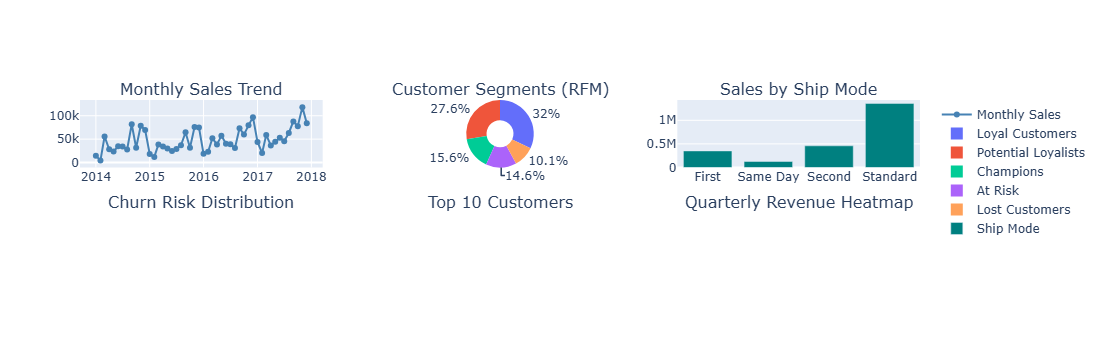

In [163]:
# Panel 3 — Ship mode
fig.add_trace(
    go.Bar(x=ship_sales['ship_mode'],
           y=ship_sales['total_sales'],
           marker_color='teal',
           name='Ship Mode'),
    row=1, col=3)

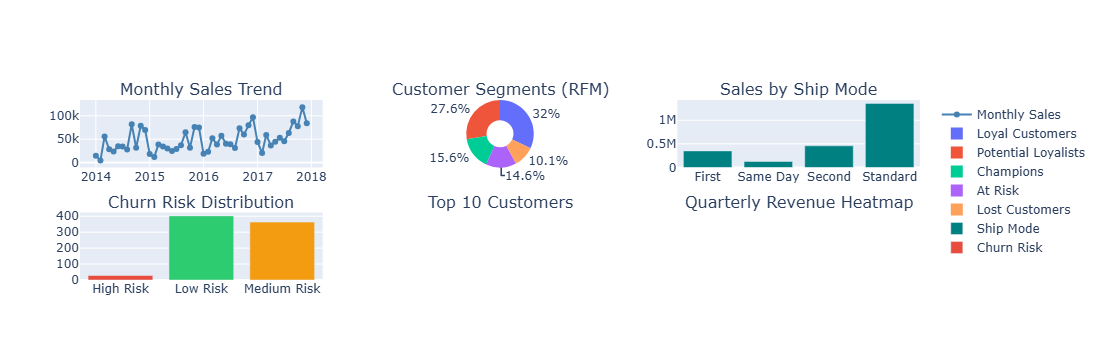

In [165]:
# Panel 4 — Churn risk
fig.add_trace(
    go.Bar(x=risk_summary['churn_risk'],
           y=risk_summary['customers'],
           marker_color=['#e74c3c', '#2ecc71', '#f39c12'],
           name='Churn Risk'),
    row=2, col=1)

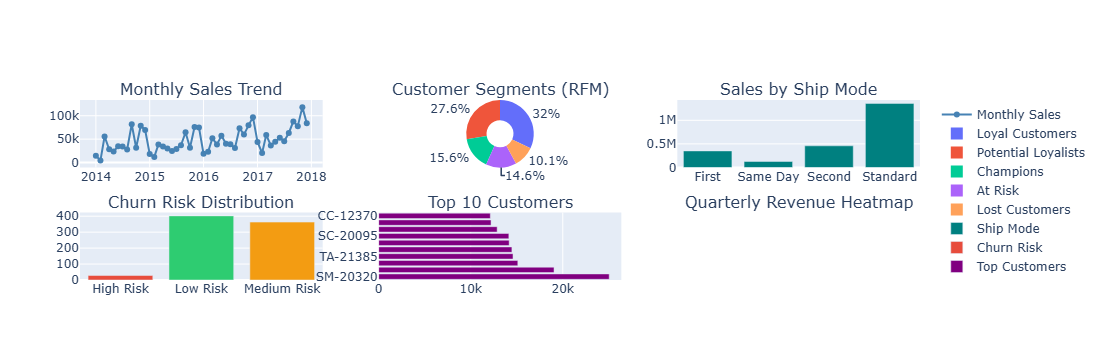

In [167]:
# Panel 5 — Top customers
fig.add_trace(
    go.Bar(x=top_customers['total_sales'],
           y=top_customers['customer_id'],
           orientation='h',
           marker_color='purple',
           name='Top Customers'),
    row=2, col=2)

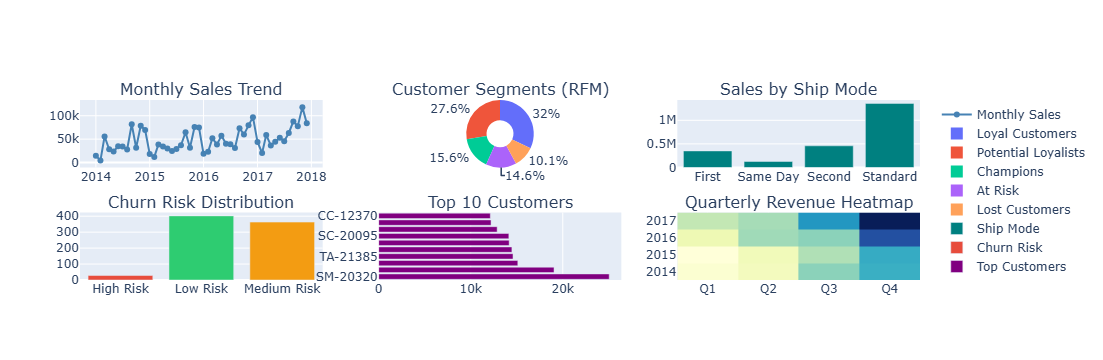

In [169]:
# Panel 6 — Quarterly heatmap
fig.add_trace(
    go.Heatmap(z=quarterly.values,
               x=[f'Q{q}' for q in quarterly.columns],
               y=quarterly.index.astype(str),
               colorscale='YlGnBu',
               showscale=False),
    row=2, col=3)

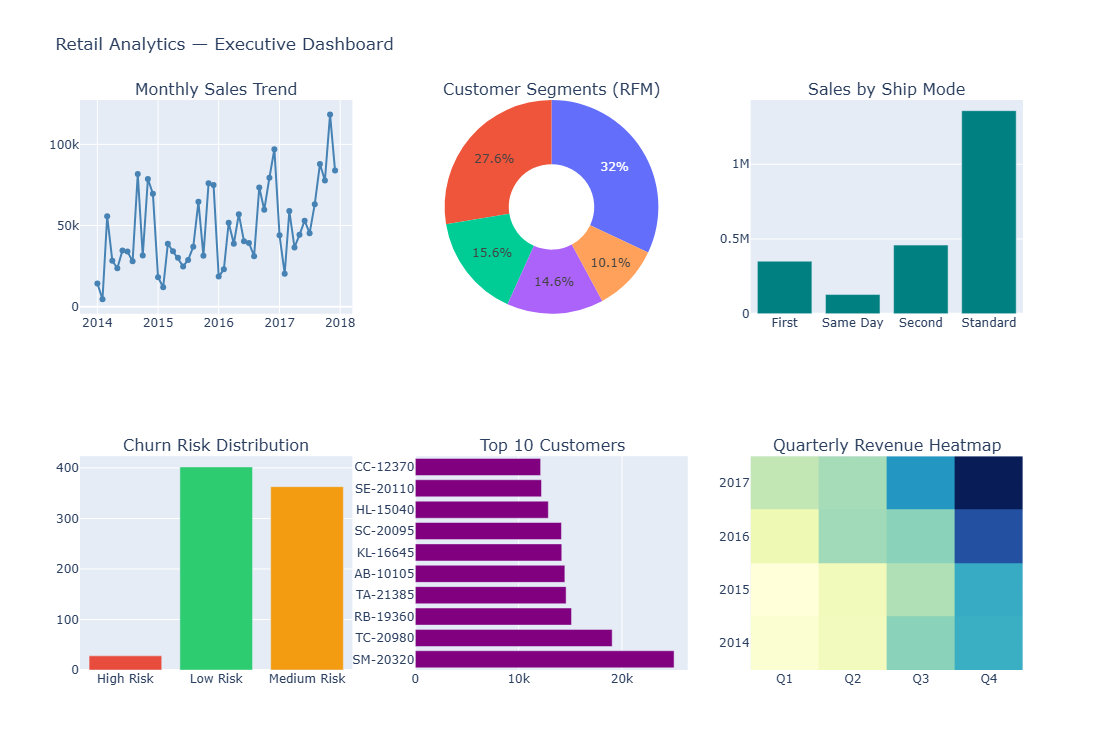


Dashboard saved to: C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\executive_dashboard.html


In [173]:
fig.update_layout(
    height=750,
    title_text='Retail Analytics — Executive Dashboard',
    showlegend=False)

fig.write_html(PATH + 'executive_dashboard.html')
fig.show()
print(f"\nDashboard saved to: {PATH}executive_dashboard.html")


## EXPORT SUMMARY TABLES

In [176]:
rfm.to_csv(PATH + 'rfm_segments.csv', index=False)
churn.to_csv(PATH + 'churn_risk.csv', index=False)
cluster_profile.to_csv(PATH + 'cluster_profiles.csv', index=False)

print("\n=== ALL FILES SAVED ===")
print(f"  rfm_segments.csv      → {PATH}")
print(f"  churn_risk.csv        → {PATH}")
print(f"  cluster_profiles.csv  → {PATH}")
print(f"  executive_dashboard.html → {PATH}")
print(f"  elbow_silhouette.png  → {PATH}")
print(f"  quarterly_heatmap.png → {PATH}")
print("\nProject complete!")


=== ALL FILES SAVED ===
  rfm_segments.csv      → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\
  churn_risk.csv        → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\
  cluster_profiles.csv  → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\
  executive_dashboard.html → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\
  elbow_silhouette.png  → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\
  quarterly_heatmap.png → C:\Users\rahul\OneDrive\Documents\PYTHON PROJECT\\

Project complete!
